У цьому ДЗ ми потренуємось розв'язувати задачу багатокласової класифікації за допомогою логістичної регресії з використанням стратегій One-vs-Rest та One-vs-One, оцінити якість моделей та порівняти стратегії.

### Опис задачі і даних

**Контекст**

В цьому ДЗ ми працюємо з даними про сегментацію клієнтів.

Сегментація клієнтів – це практика поділу бази клієнтів на групи індивідів, які схожі між собою за певними критеріями, що мають значення для маркетингу, такими як вік, стать, інтереси та звички у витратах.

Компанії, які використовують сегментацію клієнтів, виходять з того, що кожен клієнт є унікальним і що їхні маркетингові зусилля будуть більш ефективними, якщо вони орієнтуватимуться на конкретні, менші групи зі зверненнями, які ці споживачі вважатимуть доречними та які спонукатимуть їх до купівлі. Компанії також сподіваються отримати глибше розуміння уподобань та потреб своїх клієнтів з метою виявлення того, що кожен сегмент цінує найбільше, щоб точніше адаптувати маркетингові матеріали до цього сегменту.

**Зміст**.

Автомобільна компанія планує вийти на нові ринки зі своїми існуючими продуктами (P1, P2, P3, P4 і P5). Після інтенсивного маркетингового дослідження вони дійшли висновку, що поведінка нового ринку схожа на їхній існуючий ринок.

На своєму існуючому ринку команда з продажу класифікувала всіх клієнтів на 4 сегменти (A, B, C, D). Потім вони здійснювали сегментовані звернення та комунікацію з різними сегментами клієнтів. Ця стратегія працювала для них надзвичайно добре. Вони планують використати ту саму стратегію на нових ринках і визначили 2627 нових потенційних клієнтів.

Ви маєте допомогти менеджеру передбачити правильну групу для нових клієнтів.

В цьому ДЗ використовуємо дані `customer_segmentation_train.csv`[скачати дані](https://drive.google.com/file/d/1VU1y2EwaHkVfr5RZ1U4MPWjeflAusK3w/view?usp=sharing). Це `train.csv`з цього [змагання](https://www.kaggle.com/datasets/abisheksudarshan/customer-segmentation/data?select=train.csv)

**Завдання 1.** Завантажте та підготуйте датасет до аналізу. Виконайте обробку пропущених значень та необхідне кодування категоріальних ознак. Розбийте на тренувальну і тестувальну вибірку, де в тесті 20%. Памʼятаємо, що весь препроцесинг ліпше все ж тренувати на тренувальній вибірці і на тестувальній лише використовувати вже натреновані трансформери.
Але в даному випадку оскільки значень в категоріях небагато, можна зробити обробку і на оригінальних даних, а потім розбити - це простіше. Можна також реалізувати процесинг і тренування моделі з пайплайнами. Обирайте як вам зручніше.

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [119]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [120]:
data1 = pd.read_csv("drive/MyDrive/Colab Notebooks/customer_segmentation_train.csv")
data1.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


##EDA

In [121]:
data = data1.copy()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [122]:
(data.isna().mean() * 100).round(2)


,0
ID,0.00
Gender,0.00
Ever_Married,1.74
Age,0.00
Graduated,0.97
Profession,1.54
Work_Experience,10.28
Spending_Score,0.00
Family_Size,4.15
Var_1,0.94


###Ever_Married





In [123]:
data['Ever_Married'].value_counts()

,count
Ever_Married,
Yes,4643
No,3285


Заповнимо пропущені значення, перша колонка Ever_Married, бачимо, що Yes трохи більше ніж No, але все одно не зрозуміло одразу чим краще заповнити пропущені значення. Ідея - подивитись розподіл значень в зележності від віку.Потім виявити поріг - вік після якого люди частіше одружені ніж ні і заповнити пропущені значення таким правилом


<Axes: xlabel='Age'>

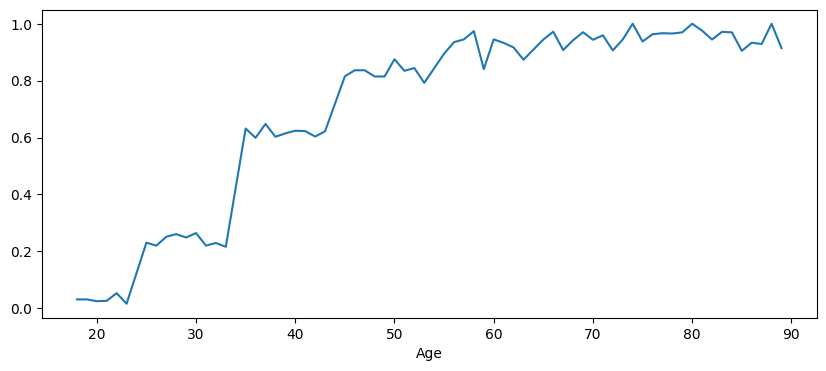

In [124]:
data['Ever_Married_num'] = data['Ever_Married'].map({'Yes': 1, 'No': 0})
data.groupby('Age')['Ever_Married_num'].mean().plot(figsize=(10,4))

In [125]:
prob_by_age = data.groupby('Age')['Ever_Married_num'].mean()
cutoff = prob_by_age[prob_by_age > 0.5].index.min()
print('cutoff', cutoff)

data.loc[data['Ever_Married'].isna(), 'Ever_Married'] = \
    np.where(data.loc[data['Ever_Married'].isna(), 'Age'] < cutoff, 'No', 'Yes')

data.drop('Ever_Married_num', axis=1, inplace=True)

cutoff 35


###Graduated

In [126]:
data['Graduated'].value_counts()

,count
Graduated,
Yes,4968
No,3022


In [127]:
data['Graduated'] = data['Graduated'].fillna(data['Graduated'].mode()[0])

###Profession


In [128]:
data['Profession'].value_counts(dropna=False)

,count
Profession,
Artist,2516
Healthcare,1332
Entertainment,949
Engineer,699
Doctor,688
Lawyer,623
Executive,599
Marketing,292
Homemaker,246


In [129]:
data['Profession'] = data['Profession'].fillna('Unknown')

 ### Work_Experience

In [130]:
data['Work_Experience'].value_counts(dropna=False)

,count
Work_Experience,
1.0,2354
0.0,2318
NaN,829
9.0,474
8.0,463
2.0,286
3.0,255
4.0,253
6.0,204


In [131]:
data['Work_Experience'] = data['Work_Experience'].fillna(-1)
data['Work_Experience_missing'] = (data['Work_Experience'] == -1).astype(int)

### Family_Size

In [132]:
data['Family_Size'].value_counts(dropna=False)

,count
Family_Size,
2.0,2390
3.0,1497
1.0,1453
4.0,1379
5.0,612
NaN,335
6.0,212
7.0,96
8.0,50


In [133]:
data['Family_Size_missing'] = data['Family_Size'].isna().astype(int)
data['Family_Size'] = data['Family_Size'].fillna(data['Family_Size'].median())


###Var_1

In [134]:
data['Var_1'].value_counts(dropna=False)

,count
Var_1,
Cat_6,5238
Cat_4,1089
Cat_3,822
Cat_2,422
Cat_7,203
Cat_1,133
Cat_5,85
NaN,76


In [135]:
data['Var_1'] = data['Var_1'].fillna('Unknown')


 Зберу EDA в зручну функцію

In [205]:
def preprocess(df):
  df.loc[df['Ever_Married'].isna(), 'Ever_Married'] = \
      np.where(df.loc[df['Ever_Married'].isna(), 'Age'] < 35, 'No', 'Yes')

  df['Graduated'] = df['Graduated'].fillna(df['Graduated'].mode()[0])

  df['Profession'] = df['Profession'].fillna('Unknown')

  df['Var_1'] = df['Var_1'].fillna('Unknown')

  df['Work_Experience_missing'] = df['Work_Experience'].isna().astype(int)
  df['Work_Experience'] = df['Work_Experience'].fillna(-1)

  df['Family_Size_missing'] = df['Family_Size'].isna().astype(int)
  df['Family_Size'] = df['Family_Size'].fillna(df['Family_Size'].median())

  df['Ever_Married'] = df['Ever_Married'].map({'No': 0, 'Yes': 1})
  df['Graduated'] = df['Graduated'].map({'No': 0, 'Yes': 1})
  df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

  score_map = {'Low': 1, 'Average': 2, 'High': 3}
  df['Spending_Score_ord'] = df['Spending_Score'].map(score_map)
  df.drop(['Spending_Score', 'ID'], axis=1, inplace=True)



  return df

In [230]:
from sklearn.model_selection import train_test_split

data2 = preprocess(data1.copy())

X = data2.drop(columns=['Segmentation'])
y = data2['Segmentation']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [231]:
from sklearn.preprocessing import OneHotEncoder

def preprocess_OHE(df_train, df_test):
  categorical_col = ['Profession', 'Var_1']
  ohenc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
  ohenc.fit(df_train[categorical_col])

  encoded_cols = list(ohenc.get_feature_names_out(categorical_col))

  df_train[encoded_cols] = ohenc.transform(df_train[categorical_col])
  df_test[encoded_cols] = ohenc.transform(df_test[categorical_col])

  df_train, df_test = df_train.drop(columns=categorical_col), df_test.drop(columns=categorical_col)

  return df_train, df_test



In [232]:
from sklearn.preprocessing import StandardScaler

def preprocess_scale(df_train, df_test):
  columns_to_scale = ['Age', 'Work_Experience', 'Family_Size']

  scaler = StandardScaler()
  scaler.fit(df_train[columns_to_scale])

  df_train[columns_to_scale] = scaler.transform(df_train[columns_to_scale])
  df_test[columns_to_scale] = scaler.transform(df_test[columns_to_scale])

  return df_train, df_test

In [233]:
from sklearn.preprocessing import OrdinalEncoder

def preprocess_ord(df_train, df_test):
  categorical_col = ['Profession', 'Var_1']

  ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

  ord_enc.fit(df_train[categorical_col])

  df_train[categorical_col] = ord_enc.transform(df_train[categorical_col])
  df_test[categorical_col]  = ord_enc.transform(df_test[categorical_col])

  cat_idx = [df_train.columns.get_loc(c) for c in categorical_col]
  return df_train, df_test, cat_idx


In [234]:
X_train_smote, X_test_smote = X_train.copy(), X_test.copy()
X_train_smotenc, X_test_smotenc = X_train.copy(), X_test.copy()

X_train_smote, X_test_smote = preprocess_OHE(X_train_smote, X_test_smote)
X_train_smote, X_test_smote = preprocess_scale(X_train_smote, X_test_smote)

X_train_smotenc, X_test_smotenc, cat_idx = preprocess_ord(X_train_smotenc, X_test_smotenc)

**Завдання 2. Важливо уважно прочитати все формулювання цього завдання до кінця!**

Застосуйте методи ресемплингу даних SMOTE та SMOTE-Tomek з бібліотеки imbalanced-learn до тренувальної вибірки. В результаті у Вас має вийти 2 тренувальних набори: з апсемплингом зі SMOTE, та з ресамплингом з SMOTE-Tomek.

Увага! В нашому наборі даних є як категоріальні дані, так і звичайні числові. Базовий SMOTE не буде правильно працювати з категоріальними даними, але є його модифікація, яка буде. Тому в цього завдання є 2 виконання

  1. Застосувати SMOTE базовий лише на НЕкатегоріальних ознаках.

  2. Переглянути інформацію про метод [SMOTENC](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTENC.html#imblearn.over_sampling.SMOTENC) і використати цей метод в цій задачі. За цей спосіб буде +3 бали за це завдання і він рекомендований для виконання.

  **Підказка**: аби скористатись SMOTENC треба створити змінну, яка містить індекси ознак, які є категоріальними (їх номер серед колонок) і передати при ініціації екземпляра класу `SMOTENC(..., categorical_features=cat_feature_indeces)`.
  
  Ви також можете розглянути варіант використання варіації SMOTE, який працює ЛИШЕ з категоріальними ознаками [SMOTEN](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTEN.html)

In [248]:
#smote

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=12)
X_train_smote_simple, y_train_smote_simple = smote.fit_resample(X_train_smote, y_train)


In [249]:
# SMOTE-Tomek

from imblearn.combine import SMOTETomek

X_train_tomek, y_train_tomek = SMOTETomek().fit_resample(X_train_smote, y_train)

In [242]:
# SMOTENC

from imblearn.over_sampling import SMOTENC

sm = SMOTENC(categorical_features=cat_idx, random_state=12)
X_train_smotenc_res, y_train_smotenc_res = sm.fit_resample(X_train_smotenc, y_train)

X_train_smotenc_res, X_test_smotenc = preprocess_OHE(X_train_smotenc_res, X_test_smotenc)
X_train_smotenc_res, X_test_smotenc = preprocess_scale(X_train_smotenc_res, X_test_smotenc)


**Завдання 3**.
  1. Навчіть модель логістичної регресії з використанням стратегії One-vs-Rest з логістичною регресією на оригінальних даних, збалансованих з SMOTE, збалансованих з Smote-Tomek.  
  2. Виміряйте якість кожної з натренованих моделей використовуючи `sklearn.metrics.classification_report`.
  3. Напишіть, яку метрику ви обрали для порівняння моделей.
  4. Яка модель найкраща?
  5. Якщо немає суттєвої різниці між моделями - напишіть свою гіпотезу, чому?

In [250]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_score, recall_score
from sklearn.multiclass import OneVsRestClassifier

In [252]:
# Логістична регресія зі стратегією one-vs-rest (OvR)
log_reg = LogisticRegression(solver='liblinear')
ovr_model = OneVsRestClassifier(log_reg)
ovr_model.fit(X_train_smote, y_train)
ovr_predictions = ovr_model.predict(X_test_smote)

# Обчислимо метрики precision та recall для кожного класу
print(classification_report(y_test, ovr_predictions))

              precision    recall  f1-score   support

           A       0.41      0.45      0.43       394
           B       0.36      0.13      0.19       372
           C       0.48      0.63      0.54       394
           D       0.64      0.76      0.70       454

    accuracy                           0.51      1614
   macro avg       0.47      0.49      0.47      1614
weighted avg       0.48      0.51      0.48      1614



In [254]:
# Логістична регресія зі стратегією one-vs-rest (OvR) + Smote
log_reg = LogisticRegression(solver='liblinear')
ovr_model = OneVsRestClassifier(log_reg)
ovr_model.fit(X_train_smote_simple, y_train_smote_simple)
ovr_predictions = ovr_model.predict(X_test_smote)

# Обчислимо метрики precision та recall для кожного класу
print(classification_report(y_test, ovr_predictions))

              precision    recall  f1-score   support

           A       0.42      0.48      0.45       394
           B       0.37      0.19      0.25       372
           C       0.50      0.61      0.55       394
           D       0.67      0.71      0.69       454

    accuracy                           0.51      1614
   macro avg       0.49      0.50      0.48      1614
weighted avg       0.50      0.51      0.50      1614



In [255]:
# Логістична регресія зі стратегією one-vs-rest (OvR) + Smote-Tomek
log_reg = LogisticRegression(solver='liblinear')
ovr_model = OneVsRestClassifier(log_reg)
ovr_model.fit(X_train_tomek, y_train_tomek)
ovr_predictions = ovr_model.predict(X_test_smote)

# Обчислимо метрики precision та recall для кожного класу
print(classification_report(y_test, ovr_predictions))

              precision    recall  f1-score   support

           A       0.40      0.48      0.44       394
           B       0.44      0.20      0.28       372
           C       0.50      0.63      0.56       394
           D       0.68      0.71      0.69       454

    accuracy                           0.52      1614
   macro avg       0.51      0.51      0.49      1614
weighted avg       0.51      0.52      0.50      1614



In [256]:
# Логістична регресія зі стратегією one-vs-rest (OvR) + SMOTENC
log_reg = LogisticRegression(solver='liblinear')
ovr_model = OneVsRestClassifier(log_reg)
ovr_model.fit(X_train_smotenc_res, y_train_smotenc_res )
ovr_predictions = ovr_model.predict(X_test_smotenc)

# Обчислимо метрики precision та recall для кожного класу
print(classification_report(y_test, ovr_predictions))

              precision    recall  f1-score   support

           A       0.41      0.49      0.45       394
           B       0.41      0.21      0.28       372
           C       0.51      0.61      0.55       394
           D       0.67      0.70      0.69       454

    accuracy                           0.52      1614
   macro avg       0.50      0.50      0.49      1614
weighted avg       0.51      0.52      0.50      1614



За метрику я взяла macro avg F1-score. Результати
- чиста OvR 0.47
- SMOTE 0.48
- SMOTE-Tomek 0.49
- SMOTENC 0.49

Видно що результати схожі, але трохи краще SMOTE-Tomek і SMOTENC. Думаю важливо ще розглянути recall клаcу B: - чиста OvR 0.13
- SMOTE  0.19
- SMOTE-Tomek 0.20
- SMOTENC 0.21

Тобто SMOTENC найкраще підняв recall для B. Отже можемо визначити SMOTENC як найкращу модель

Моя гіпотеза щодо відсутності суттєвої різниці. Класи з самого початку майже збалансовані, тому ресемплінг не дає супер результату.

In [261]:
data1['Segmentation'].value_counts(normalize=True)

,proportion
Segmentation,
D,0.281111
A,0.244422
C,0.244175
B,0.230293
